In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text 
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.preprocessing import MultiLabelBinarizer
import re 
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from huggingface_hub import snapshot_download
from transformers import AutoModelForSequenceClassification, AutoTokenizer


In [3]:
df_admits = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar_detail.csv.gz', compression='gzip')


In [ ]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar_detail.csv.gz', compression='gzip')


In [26]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13
5,10000102,F,27,2136,2008 - 2010,NaN
6,10000108,M,25,2163,2014 - 2016,NaN
7,10000115,M,24,2154,2017 - 2019,NaN
8,10000117,F,48,2174,2008 - 2010,NaN
9,10000161,M,60,2163,2020 - 2022,NaN


In [ ]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


In [ ]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [12]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [ ]:
pd.set_option('display.max_columns', None)
df_icd_proc[df_icd_proc['icd_code']=='2764'].head(5)
#df_icd_diagnosis.head(5)

In [ ]:
# 1. 
# 
# Check for how many diagnosis that exist - will need to group diagnosis first for easier encoding
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')


In [13]:
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('No ICD Code')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [ ]:
icd_counts = df_admit_diagnosis.icd_code.value_counts()

df_admit_diagnosis.drop(columns = ['icd_version_y','icd_version_x','edregtime','edouttime','deathtime','admit_provider_id','hospital_expire_flag',
                                          'seq_num','icd_code','language','icd_version'],inplace = True)

In [15]:
pd.set_option('display.max_rows', 10000)    
print(df_admit_diagnosis.icd_code_converted.value_counts().head(10000))

icd_code_converted
Other Code     1457032
4019            102368
E785             84570
I10              83775
2724             67293
Z87891           62806
K219             56157
53081            48628
25000            43077
F329             41876
I2510            41550
F419             38911
42731            37070
4280             36606
311              36349
41401            36083
N179             35884
Z20822           33113
V1582            31705
Z7901            30957
5849             29136
2449             28521
E039             28000
Z794             27642
E119             26266
3051             25879
2859             24395
F17210           24106
G4733            23933
40390            23831
V5861            22635
30000            22399
E669             22004
V270             21238
D649             21137
I4891            21022
J45909           20679
5990             20387
Z7902            19961
2720             19880
Y929             19830
49390            19703
V5867          

In [68]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,marital_status,race,icd_diagnosis_name,proc_name,anchor_age,gender,icd_code_converted
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Portal hypertension,No Procedure,52,F,5723
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Other ascites,No Procedure,52,F,78959
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Cirrhosis of liver without mention of alcohol,No Procedure,52,F,5715
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Unspecified viral hepatitis C without hepatic ...,No Procedure,52,F,07070
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,"Chronic airway obstruction, not elsewhere clas...",Excision of anus,52,F,496


Clustering Text Fields

Text cluster diagnosis using DBSCAN and TF-ID Vectorisation for diagnosis - better for no set k

In [4]:
def custom_preprocessor(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove all digits
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and whitespace
    return text

In [10]:
# Inital vectorizer step is key for good clustering - add in custom conditions for stop words and removal of common words

# Stop words are a mixture of general medical terms, body terms, locaton words, redundant terms and temporal words
my_stop_words = ['disease','term','episode','eyes', 'face', 'facial','mouth','home','legs','pain'
                 ,'procedure','weight','adult','child','unspecified','primary','secondary','other','long'
                 ,'disease', 'disorder', 'syndrome', 'condition', 'acute', 'chronic'
                 ,'system', 'due', 'related', 'associated', 'organ', 'tissue', 'area', 'region', 'tract'
                 ,'side', 'lobe', 'part', 'left', 'right', 'bilateral', 'upper', 'lower',   'anterior'
                 ,'posterior', 'icd', 'code','type', 'specified', 'classification'
                 ,'history', 'present', 'past','recent', 'new', 'old','accessory','adhesive','body', 'blood', 
                 'unspecified'
                 ]
combined_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))

vectorizer_d = TfidfVectorizer(
                            preprocessor=custom_preprocessor,
                            stop_words=combined_stop_words, 
                            ngram_range=(1, 2),     # combines phrases  
                            min_df=10,              # remove rare junk terms
                            max_df=0.80,           # removes words in column/document that appear in > 90% of doc
                            #max_features=1000
                             )          



In [16]:
# Isolate all diagnosis for easier vectorisation
unique_diagnosis_groups = df_admit_diagnosis['icd_diagnosis_name'].dropna().unique()
unique_diagnosis_groups

array(['Portal hypertension', 'Other ascites',
       'Cirrhosis of liver without mention of alcohol', ...,
       'Twin pregnancy, unable to determine number of placenta and number of amniotic sacs, third trimester',
       'Driver of special industrial vehicle injured in nontraffic accident, initial encounter',
       'Maternal care for (suspected) fetal abnormality and damage, unspecified, fetus 2'],
      shape=(27466,), dtype=object)

In [ ]:
vectorized_words_d = vectorizer_d.fit_transform(unique_diagnosis_groups)
tfidf_cols = vectorizer_d.get_feature_names_out()
print(tfidf_cols[1:1000])

['abdomen pelvis' 'abdominal' 'abdominal tenderness' 'abdominal wall'
 'abnormal' 'abnormal findings' 'abnormal reaction' 'abnormal results'
 'abnormalities' 'abnormality' 'abortion' 'abortion complicated'
 'abrasion' 'abrasion friction' 'abscess' 'abscess bleeding' 'absence'
 'abuse' 'abuse intoxication' 'abuse remission' 'abuse withdrawal'
 'accident' 'accident boarding' 'accident caused' 'accident initial'
 'accident injuring' 'accident involving' 'accident nature'
 'accident nontraffic' 'accident sequela' 'accident subsequent'
 'accident traffic' 'accidental' 'accidental drowning' 'accidental fall'
 'accidental poisoning' 'accidental puncture' 'accidental unintentional'
 'accidentally' 'accidentally following' 'accidentally purposely'
 'accidents' 'accidents caused' 'acetabulum' 'acetabulum initial'
 'achieved' 'achieved remission' 'achilles' 'achilles tendon' 'acid'
 'acquired' 'acquired absence' 'acquired deformities' 'acquired deformity'
 'acquired foot' 'acromioclavicular' 'acr

In [58]:
# # this step is needed to reduce data size (dimensionality reduction) due to too many features & sparse matrix
# pca = PCA(random_state=42)
# reduced_data_i = pca.fit_transform(vectorized_words_d)

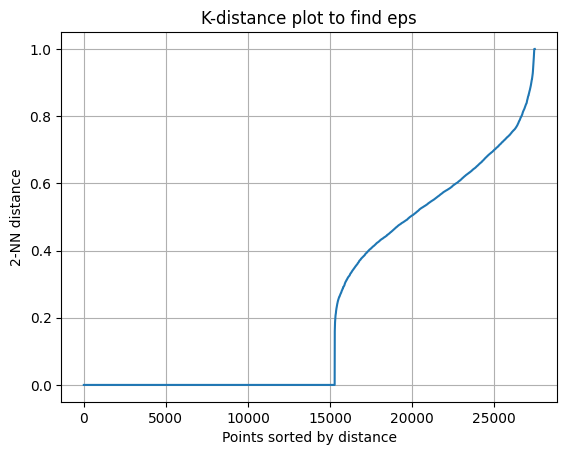

In [14]:
min_samples = 2
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(vectorized_words_d)
distances, indices = neighbors_fit.kneighbors(vectorized_words_d)
# Take the k-distance (distance to the k-th nearest neighbor)
k_distances = np.sort(distances[:, -1])  # -1 gets the farthest (k-th neighbor)
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance plot to find eps")
plt.grid(True)
plt.show()


In [15]:
for eps in [0.2, 0.3, 0.4, 0.5,0.6,0.7,0.8]:
    for min_samples in [2, 3, 5,10]:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
        labels = db.fit_predict(vectorized_words_d)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        print(f"eps={eps}, min_samples={min_samples} → clusters: {n_clusters}")

eps=0.2, min_samples=2 → clusters: 3765
eps=0.2, min_samples=3 → clusters: 2377
eps=0.2, min_samples=5 → clusters: 1295
eps=0.2, min_samples=10 → clusters: 444
eps=0.3, min_samples=2 → clusters: 1544
eps=0.3, min_samples=3 → clusters: 1120
eps=0.3, min_samples=5 → clusters: 899
eps=0.3, min_samples=10 → clusters: 618
eps=0.4, min_samples=2 → clusters: 259
eps=0.4, min_samples=3 → clusters: 179
eps=0.4, min_samples=5 → clusters: 149
eps=0.4, min_samples=10 → clusters: 179
eps=0.5, min_samples=2 → clusters: 38
eps=0.5, min_samples=3 → clusters: 24
eps=0.5, min_samples=5 → clusters: 23
eps=0.5, min_samples=10 → clusters: 26
eps=0.6, min_samples=2 → clusters: 2
eps=0.6, min_samples=3 → clusters: 2
eps=0.6, min_samples=5 → clusters: 2
eps=0.6, min_samples=10 → clusters: 2
eps=0.7, min_samples=2 → clusters: 2
eps=0.7, min_samples=3 → clusters: 2
eps=0.7, min_samples=5 → clusters: 2
eps=0.7, min_samples=10 → clusters: 2
eps=0.8, min_samples=2 → clusters: 1
eps=0.8, min_samples=3 → clusters: 1

In [16]:
# DBSCAN clustering
dbscan_d = DBSCAN(eps=0.3, min_samples=10, metric = 'cosine')
clusters_unique_d = dbscan_d.fit_predict(vectorized_words_d)

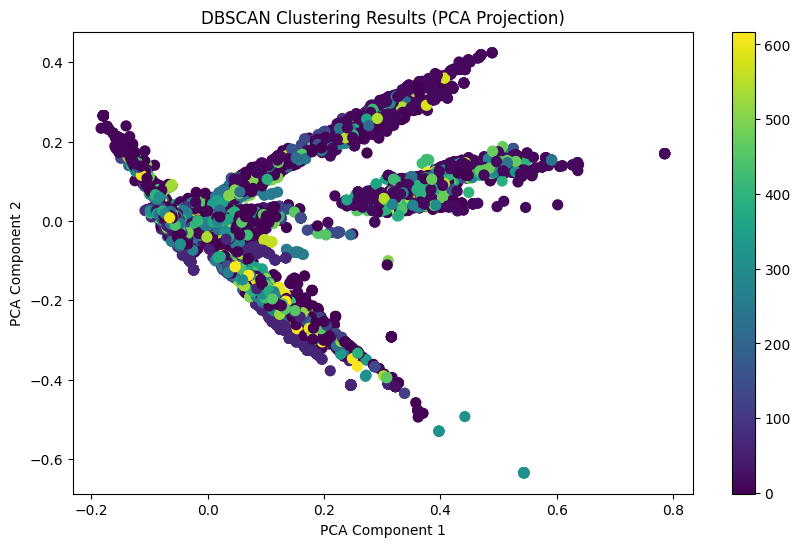

In [17]:
pca = PCA(random_state=42)
Y_2d = PCA(n_components=2).fit_transform(vectorized_words_d.toarray())
# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(Y_2d[:, 0], Y_2d[:, 1], c=clusters_unique_d, cmap='viridis', s=50)
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [18]:
#pd.reset_option('max_rows')
group_cluster_map_diagnosis = pd.DataFrame({
    'icd_diagnosis_name': unique_diagnosis_groups,
    'cluster': clusters_unique_d
})

In [19]:
group_cluster_map_diagnosis.cluster.value_counts()

cluster
-1      9866
 13     1340
 7       652
 65      617
 95      249
 24      234
 123     189
 228     162
 60      160
 89      153
 238     143
 16      142
 180     138
 61      129
 78      125
 261     125
 278     115
 38      115
 22      108
 388     104
 87      104
 197      98
 8        96
 72       91
 277      89
 175      87
 189      85
 242      84
 227      82
 165      82
 232      80
 397      78
 114      78
 135      73
 63       72
 407      71
 318      69
 455      68
 401      68
 314      66
 190      64
 53       64
 389      64
 361      63
 255      63
 140      62
 86       61
 403      59
 12       58
 75       57
 34       56
 534      55
 151      53
 17       53
 423      52
 349      51
 83       51
 351      50
 37       50
 323      50
 321      49
 21       49
 27       48
 118      48
 169      48
 58       48
 301      46
 333      46
 280      45
 312      45
 39       45
 229      45
 187      45
 304      44
 247      44
 125      44
 120

Text cluster diagnosis using BiomedBERT for diagnosis

In [ ]:
snapshot_download(repo_id="microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext", repo_type="model")

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\smahmood\.cache\huggingface\hub\models--microsoft--BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(

'C:\\Users\\smahmood\\.cache\\huggingface\\hub\\models--microsoft--BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext\\snapshots\\e1354b7a3a09615f6aba48dfad4b7a613eef7062'

In [6]:
model_path = r"\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\models--dmis-lab--biobert-base-cased-v1.1"
# Download and save tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModel.from_pretrained(model_path,local_files_only=True)


In [7]:
model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [8]:
def encode_texts(texts, batch_size=32):
    all_embeddings = []
    texts = [str(t) for t in texts]  # Ensure all items are strings

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded_input = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors='pt')

        with torch.no_grad():
            output = model(**encoded_input)
            last_hidden_state = output.last_hidden_state
            attention_mask = encoded_input['attention_mask']

            mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size())
            sum_embeddings = torch.sum(last_hidden_state * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            mean_embeddings = sum_embeddings / sum_mask

            all_embeddings.append(mean_embeddings.numpy())

    return np.vstack(all_embeddings)

In [55]:
def custom_preprocessor_with_stop_words(text_input):
    text_input = text_input.lower()
    text_input = re.sub(r'\d+', '', text_input)                 # Remove digits
    text_input = re.sub(r'[^a-z\s]', '', text_input)            # Keep only letters and spaces
    tokens = text_input.split()                                 # Tokenize
    filtered_tokens = [word for word in tokens if word not in combined_stop_words]  # Remove stop words
    return ' '.join(filtered_tokens)

In [56]:
# Step 4: Run encoding
processed_diag_list = [custom_preprocessor_with_stop_words(text) for text in unique_diagnosis_groups]
diagnosis_embeddings = encode_texts(processed_diag_list)

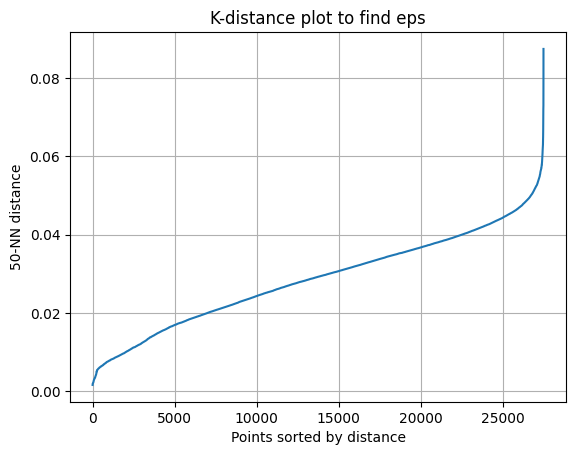

In [57]:
min_samples = 50
neighbors = NearestNeighbors(n_neighbors=min_samples, metric='cosine')
neighbors_fit = neighbors.fit(diagnosis_embeddings)
distances, indices = neighbors_fit.kneighbors(diagnosis_embeddings)
# Take the k-distance (distance to the k-th nearest neighbor)
k_distances = np.sort(distances[:, -1])  # -1 gets the farthest (k-th neighbor)
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance plot to find eps")
plt.grid(True)
plt.show()


In [50]:
for eps in [0.04,0.045,0.05]:
    for min_samples in [10,20,30,50]:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        labels = db.fit_predict(diagnosis_embeddings)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        print(f"eps={eps}, min_samples={min_samples} → clusters: {n_clusters}")

eps=0.04, min_samples=10 → clusters: 4
eps=0.04, min_samples=20 → clusters: 3
eps=0.04, min_samples=30 → clusters: 2
eps=0.04, min_samples=50 → clusters: 0
eps=0.045, min_samples=10 → clusters: 4
eps=0.045, min_samples=20 → clusters: 3
eps=0.045, min_samples=30 → clusters: 2
eps=0.045, min_samples=50 → clusters: 0
eps=0.05, min_samples=10 → clusters: 4
eps=0.05, min_samples=20 → clusters: 3
eps=0.05, min_samples=30 → clusters: 2
eps=0.05, min_samples=50 → clusters: 0


In [66]:
# DBSCAN clustering
dbscan_b = DBSCAN(eps=0.05, min_samples=10, metric = 'cosine')
clusters_unique_b = dbscan_b.fit_predict(diagnosis_embeddings)

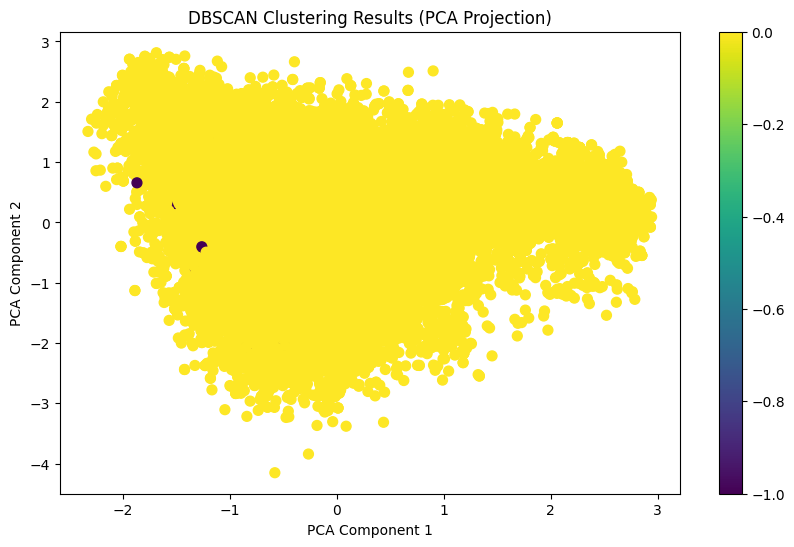

In [67]:
pca = PCA(random_state=42)
Y_2d = PCA(n_components=2).fit_transform(diagnosis_embeddings)
# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(Y_2d[:, 0], Y_2d[:, 1], c=clusters_unique_b, cmap='viridis', s=50)
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [64]:
#pd.reset_option('max_rows')
group_cluster_map_diagnosis_dbscan = pd.DataFrame({
    'icd_diagnosis_name': unique_diagnosis_groups,
    'cluster': clusters_unique_b
})

In [65]:
group_cluster_map_diagnosis_dbscan.cluster.value_counts()

cluster
 0    27444
-1       22
Name: count, dtype: int64

In [ ]:
# Join encoded diagnosis later

df_admit_diagnosis_diagnosis_encoded = df_admit_diagnosis.merge(group_cluster_map_diagnosis, on='icd_diagnosis_name', how='left')
df_admit_diagnosis_diagnosis_encoded

Cluster Medication Data

In [ ]:
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

In [ ]:
# Define grouping rules for usage
administered = [
    'Administered', 'Partial Administered', 'Applied',
    'Confirmed', 'Started', 'Administered in Other Location',
    'Started in Other Location', 'Administered Bolus from IV Drip',
    'Applied in Other Location', 'Removed Existing / Applied New',
    'Removed Existing / Applied New in Other Location',
    'Restarted', 'Restarted in Other Location'
]

not_administered = [
    'Not Applied', 'Not Given', 'Not Flushed', 'Hold Dose', 'Removed',
    'Not Confirmed', 'Not Started', 'Not Assessed', 'Not Removed',
    'Not Stopped', 'Not Read', 'Not Given per Sliding Scale',
    'Not Stopped per Sliding Scale', 'Not Started per Sliding Scale',
    'Not Given per Sliding Scale in Other Location', 'Read', 'Read in Other Location', 'Stopped', 'Stopped As Directed',
    'Stopped - Unscheduled', 'Stopped - Unscheduled in Other Location',
    'Rate Change', 'Rate Change in Other Location','Removed in Other Location',
    'Confirmed in Other Location'

]

delayed = [s for s in df_medi['event_txt'].dropna().unique() if s.startswith('Delayed')]

other = [
    'Flushed', 'Flushed in Other Location', 'Assessed',
    'Assessed in Other Location', 'Infusion Reconciliation',
    'Infusion Reconciliation Not Done', 'Pain score re-assessment',
    'Pain score re-assess not done', 'Documented in O.R. Holding',
    'TPN Rate Not Changed', ' in Other Location', 'Partial ',
]

In [ ]:
# Make sure event lists are sets for faster lookup
administered_set = set(administered)
not_administered_set = set(not_administered)
delayed_set = set(delayed)

# Initialize with 'Other'
df_medi['usage'] = 'Other'

# Apply conditions using boolean indexing
mask_admin = df_medi['event_txt'].isin(administered_set) & (df_medi['medication'] != 'No Medication')
mask_not_admin = df_medi['event_txt'].isin(not_administered_set)
mask_delayed = df_medi['event_txt'].isin(delayed_set)

df_medi.loc[mask_admin, 'usage'] = 'Administered'
df_medi.loc[mask_not_admin, 'usage'] = 'Not Administered'
df_medi.loc[mask_delayed, 'usage'] = 'Delayed'

# Filter to only include 'Administered'
df_medi = df_medi[df_medi['usage'] == 'Administered']
df_medi['medication'] = df_medi['medication'].str.lower()

In [ ]:
df_medi[df_medi['usage']=='Administered']

In [ ]:
med_counts = df_medi.medication.value_counts()
df_medi['medication_grouped'] = df_medi.medication.apply(lambda x: str(x) if med_counts[x] > 10000 else ('other medication' if med_counts[x] < 10000 else 'no medication'))

In [ ]:
unique_med_groups = df_medi['medication_grouped'].dropna().unique()

In [ ]:
# Using Euclidean on TF-IDF makes clusters based on magnitude, not semantic similarity
# Using metric='cosine' makes clusters based on angle (i.e., similarity of meaning)
# Options:
# Raw numeric featuresmetric='euclidean' (default, fine)
# TF-IDF / text vectors metric='cosine'
# Precomputed distance matrix metric='precomputed'
# Custom distance function metric=your_func

# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(unique_med_groups)

In [ ]:
# X_unique: your TF-IDF or SVD-reduced matrix
min_samples = 2
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Take the k-distance (distance to the k-th nearest neighbor)
k_distances = np.sort(distances[:, -1])  # -1 gets the farthest (k-th neighbor)
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance plot to find eps")
plt.grid(True)
plt.show()

In [ ]:
for eps in [0.2, 0.3, 0.4, 0.5,0.6,0.7,0.8]:
    for min_samples in [2, 3, 5]:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        print(f"eps={eps}, min_samples={min_samples} → clusters: {n_clusters}")


In [ ]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.6, min_samples=2, metric = 'cosine')
clusters_unique = dbscan.fit_predict(X)

In [ ]:
X_2d = PCA(n_components=2).fit_transform(X.toarray())

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_unique, cmap='viridis', s=50)
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [ ]:
#pd.reset_option('max_rows')
group_cluster_map = pd.DataFrame({
    'medication_grouped': unique_med_groups,
    'cluster': clusters_unique
})

In [ ]:
group_cluster_map.cluster.value_counts()

In [ ]:
df_medi = df_medi.merge(group_cluster_map, on='medication_grouped', how='left')
df_medi

Encoding Data

In [ ]:
# Group first to reduce data size
df_admit_diagnosis_grouped = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'marital_status': 'first',
     'race':'first',
     'anchor_age': 'first',
     'gender':'first',
     'icd_code_converted': lambda x: set(x),
     'icd_diagnosis_name': lambda x: set(x),
     'proc_name': lambda x: set(x),
     }).reset_index()
df_admit_diagnosis_grouped.head(5)  

In [ ]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

df_admit_diagnosis_grouped['admittime'] = pd.to_datetime(df_admit_diagnosis_grouped['admittime'])
df_admit_diagnosis_grouped['dischtime'] = pd.to_datetime(df_admit_diagnosis_grouped['dischtime'])

df_admit_diagnosis_grouped['admission_rank'] = df_admit_diagnosis_grouped.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_grouped.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_grouped['last_dischtime'] = df_admit_diagnosis_grouped.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_grouped['days_from_last'] = (df_admit_diagnosis_grouped['admittime'] - df_admit_diagnosis_grouped['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_grouped['readmission'] = df_admit_diagnosis_grouped['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

#df_admit_diagnosis_grouped[df_admit_diagnosis_grouped['subject_id'] == 10000032]

In [ ]:
# label encode the text columns
df_admit_diagnosis_encoded = df_admit_diagnosis_grouped.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 'admission_rank']) # drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender','marital_status']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


In [ ]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_admit_diagnosis_encoded['icd_code_converted'])

df_icd_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_admit_diagnosis_encoded['hadm_id'],
    columns=mlb.classes_
)

In [ ]:
df_admit_diagnosis_icd_encoded = pd.merge(
    df_admit_diagnosis_encoded,
    df_icd_encoded,
    on='hadm_id'
)

In [ ]:
print("Length of Original Data: ",len(df_admit_diagnosis_encoded))
print("Length of Data After MLB: ",len(df_admit_diagnosis_icd_encoded))

In [ ]:
df_admit_diagnosis_icd_encoded.head()

In [ ]:
# Use Elbow Method to determine the number of clusters to use

inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced_data)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias.append(kmeans.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
num_clusters=4
kmeans = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans.fit(vectorized_words)

In [ ]:
for i in range(num_clusters):
    plt.scatter(reduced_data[kmeans.labels_ == i, 0], 
                reduced_data[kmeans.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Various Diagnosis')
plt.show()

In [ ]:
df_admit_diagnosis = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'cluster': lambda x: set(x),
     }).reset_index()

In [ ]:
mlb = MultiLabelBinarizer(sparse_output=True)
X1 = mlb.fit_transform(df_admit_diagnosis['cluster'])
df_icd_encoded = pd.DataFrame.sparse.from_spmatrix(
    X1,
    index=df_admit_diagnosis['hadm_id'],
    columns=mlb.classes_

)
df_admit_diagnosis = pd.merge(
   df_admit_diagnosis,
    df_icd_encoded,
    on='hadm_id'
)


In [ ]:
df_admit_diagnosis

In [ ]:
df_medi_agg = df_medi.groupby(['hadm_id', 'subject_id']).agg({  
     'cluster': lambda x: set(x),
     }).reset_index()

In [ ]:
Y = mlb.fit_transform(df_medi_agg['cluster'])

df_medi_encoded = pd.DataFrame.sparse.from_spmatrix(
    Y,
    index=df_medi_agg['hadm_id'],
    columns=mlb.classes_
)

In [ ]:
df_medi_encoded = pd.merge(df_medi_agg,df_medi_encoded, on = 'hadm_id')

In [ ]:
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
pd.reset_option('display.max_columns')
df_medi_encoded.head()

In [ ]:
# Merge both encoded tables
#1 
df_full_dataset = pd.merge(
    df_admit_diagnosis_icd_encoded,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)
df_full_dataset.fillna(0, inplace=True)

In [ ]:
# Merge both encoded tables
#2
df_full_dataset = pd.merge(
    df_admit_diagnosis,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)
df_full_dataset.fillna(0, inplace=True)

In [ ]:
pd.set_option('display.max_columns', None)
df_full_dataset

Build Logistic Regression Model

In [ ]:
df_full_dataset.drop(columns= ['medication_grouped','subject_id_y','icd_code_converted','icd_diagnosis_name','proc_name'],inplace=True)

In [ ]:
df_full_dataset.drop(columns= ['cluster_x','subject_id_y','cluster_y'],inplace=True)

In [ ]:
# correlation matrix
corr_matrix = df_full_dataset.corr()

plt.figure(figsize=(15, 15))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = df_full_dataset.select_dtypes(include='number').corr().abs()

# Unstack and filter
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # upper triangle, no self-pairs
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'})
)

# Filter and sort
high_corr_filtered = high_corr[high_corr['Correlation'] > 0.5].sort_values(by='Correlation', ascending=False)

print(high_corr_filtered.head(50))